In [ ]:
from pathlib import Path
import sys

# Make this package's scripts/ importable (exp_info, regions, data_utils, ...).
PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts" / "exp_info.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start this notebook from inside the polar_analysis package.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

In [ ]:
# Parameters: directories and settings for this run. Edit them for another
# machine or experiment, or override with papermill (-p NAME VALUE).
FIG_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper/figures/time_series_nmsk"  # output figures
DATA_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper/data"  # input; area_mean_ts files in DATA_DIR/<region>/ (process_ts_area_mean)


In [11]:
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
from collections import OrderedDict
from typing import Optional, Tuple, Set

import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# --- Imports
from pathlib import Path    
from data_utils import (
    REFERENCE_VAR_DICT,
    define_region,
    list_regions, 
    gen_land_mask, 
    gen_ice_mask,
    normalize_longitude,
    get_run_meta,
    list_runs,
    get_var_meta,
    get_levels,
)

In [20]:
class AnnualAnomalyPlotter:
    def __init__(
        self, data_dir, file_template, num_ens, var_dict,
        var_key, var_type, season="ANN",
        fig_dir=None, chunks=None, fontz=12
    ):
        self.season = season
        self.data_dir = data_dir
        self.file_template = file_template
        self.num_ens = num_ens
        self.var_dict = var_dict
        self.var_key = var_key
        self.var_type = var_type                    # "anomaly" or "raw"
        self.include_raw_when_anomaly = True        # <-- NEW: keep RAW alongside D* when plotting anomalies
        self.fig_dir = fig_dir or data_dir
        self.fontz = fontz
        self.chunks = chunks
        self.time_coord = None
        self.bad_files = []

    # ---------- name parsing helpers ----------
    def _has_D(self, s: str) -> bool:
        return s.startswith("D")

    def _strip_D(self, s: str) -> str:
        return s[1:] if s.startswith("D") else s

    def _maybe_add_D(self, s: str) -> str:
        return s if s.startswith("D") or self.var_type != "anomaly" else "D" + s

    def _best_base_match(self, s_woD: str):
        keys = list(self.var_dict.keys())
        cands = [k for k in keys if (s_woD == k) or s_woD.startswith(k + "_")]
        if cands:
            base = max(cands, key=len)
            rest = s_woD[len(base):]
            suffix = rest if (rest and rest.startswith("_")) else (("_" + rest) if rest else "")
            return base, suffix
        parts = s_woD.split("_")
        if len(parts) >= 2:
            base = "_".join(parts[:2])
            suffix = "" if len(parts) == 2 else "_" + "_".join(parts[2:])
        else:
            base = s_woD; suffix = ""
        return base, suffix

    def _target_signature(self, var_name: str):
        expect_anom = (self.var_type == "anomaly")
        base, _suffix = self._split_base_suffix(self._resolve_varname(var_name), expect_anom=expect_anom)
        req_suffix = f"_{self.var_key}" if self.var_key else ""
        return expect_anom, base, req_suffix

    def _resolve_existing_var(self, ds, var_name: str):
        expect_anom, base_tgt, req_suffix = self._target_signature(var_name)
        exact, loose = [], []
        for v in ds.data_vars:
            is_anom = v.startswith("D")
            if expect_anom and not is_anom:
                continue
            if (not expect_anom) and is_anom:
                continue
            base_v, suffix_v = self._split_base_suffix(v, expect_anom=is_anom)
            if base_v == base_tgt:
                if req_suffix and suffix_v.endswith(req_suffix):
                    exact.append(v)
                else:
                    loose.append(v)
        if exact:
            return max(exact, key=len)
        if loose:
            cand = max(loose, key=len)
            print(f'[WARN] Using "{cand}" for "{self._resolve_varname(var_name)}" (suffix mismatch).')
            return cand
        return None

    def _split_base_suffix(self, name: str, expect_anom: bool = None):
        if expect_anom is None:
            expect_anom = (self.var_type == "anomaly")
        s_woD = self._strip_D(name) if expect_anom else name
        return self._best_base_match(s_woD)

    # ---------- variable name resolution ----------
    def _resolve_varname(self, var_name: str) -> str:
        base_in, suffix_in = self._split_base_suffix(var_name, expect_anom=None)
        suffix = suffix_in or ""
        if self.var_key:
            tail = f"_{self.var_key}"
            if not suffix.endswith(tail):
                suffix = (suffix + tail) if suffix else tail
        name = base_in + suffix
        if self.var_type == "anomaly":
            name = self._maybe_add_D(name)
        else:
            name = self._strip_D(name)
        name = re.sub(r"__+", "_", name)
        name = re.sub(r"^D_", "D", name)
        return name

    def _scale_for(self, var_name: str) -> float:
        return float(self.var_dict.get(var_name, {}).get("scale", 1.0))

    def _apply_scaling(self, ds):
        updates = {}
        expect_anom = (self.var_type == "anomaly")
        for v in ds.data_vars:
            is_anom = v.startswith("D")
            base, _ = self._split_base_suffix(v, expect_anom=is_anom)
            meta = self.var_dict.get(base, {})
            scale = float(meta.get("scale", 1.0))
            if scale != 1.0:
                da = ds[v] * scale
                new_attrs = dict(ds[v].attrs)
                if "unit" in meta:
                    new_attrs["units"] = meta.get("unit", new_attrs.get("units", None))
                new_attrs["scale_applied"] = scale
                updates[v] = da.assign_attrs(new_attrs)
        return ds.assign(**updates) if updates else ds

    def _single_ens_chunk(self, da):
        arr = getattr(da, "data", None)
        if hasattr(arr, "chunks") and ("ens" in da.dims):
            axis = da.get_axis_num("ens")
            ch = arr.chunks[axis]
            if len(ch) > 1:
                return da.chunk({"ens": -1})
        return da

    # ---------- file discovery & validation ----------
    def _ensemble_paths(self):
        import os
        paths = []
        for i in range(0, self.num_ens + 1):
            ens_str = str(i).zfill(2)
            fname = self.file_template.replace("%(ENS)", ens_str)
            paths.append(os.path.join(self.data_dir, fname))
        paths = [p for p in paths if os.path.isfile(p)]
        if not paths:
            raise FileNotFoundError("No ensemble files found after filtering missing files.")
        return paths

    def _looks_ok(self, name: str, bases, suffix, expect_anom) -> bool:
        base, found_suffix = self._split_base_suffix(name, expect_anom=expect_anom)
        has_suffix = found_suffix.endswith(suffix) if suffix else True
        return (base in bases) and has_suffix

    def find_bad_files(self, engine="netcdf4", decode_times=True, extra_checks=True):
        import os
        import xarray as xr
        paths = self._ensemble_paths()
        good, bad = [], []
        for p in paths:
            try:
                with xr.open_dataset(p, engine=engine, decode_times=decode_times) as ds:
                    _ = list(ds.sizes.items())
                    _ = [ds[c].shape for c in ds.coords]
                    if extra_checks:
                        bases  = set(self.var_dict.keys())
                        req_suffix = f"_{self.var_key}" if self.var_key else ""
                        def _ok_any(v):
                            is_anom = v.startswith("D")
                            if self.var_type == "raw" and is_anom:
                                return False
                            if self.var_type == "anomaly" and (not is_anom) and (not self.include_raw_when_anomaly):
                                return False
                            b, s = self._split_base_suffix(v, expect_anom=is_anom)
                            return (b in bases) and (s.endswith(req_suffix) if req_suffix else True)

                        if not any(_ok_any(v) for v in ds.data_vars):
                            raise RuntimeError("No expected variables present for requested type/suffix.")
                        ds2 = self._preprocess(ds)
                        if len(ds2.data_vars) == 0:
                            raise RuntimeError("No expected variables left after preprocess.")
                    if ("year" not in ds.coords) and ("time" not in ds.coords) and ("year" not in ds):
                        raise RuntimeError("Missing 'year'/'time' coordinate.")
                good.append(p)
            except Exception as e:
                bad.append({"path": p, "error": f"{type(e).__name__}: {e}"})
        self.bad_files = bad
        if bad:
            report = os.path.join(self.fig_dir, "bad_ensemble_files.txt")
            import os as _os
            _os.makedirs(self.fig_dir, exist_ok=True)
            try:
                with open(report, "w") as f:
                    f.write(f"Found {len(bad)} problematic files:\n")
                    for b in bad:
                        f.write(f"- {b['path']} :: {b['error']}\n")
                print(f"[WARN] {len(bad)} bad files. Report: {report}")
            except Exception as e:
                print(f"[WARN] Could not write bad-file report ({e}).")
        else:
            print("[INFO] All ensemble files opened cleanly.")
        return good, bad

    def _preprocess(self, ds):
        bases  = set(self.var_dict.keys())
        req_suffix = f"_{self.var_key}" if self.var_key else ""
        keep = []
        expect_anom = (self.var_type == "anomaly")
        keep_raw_also = expect_anom and getattr(self, "include_raw_when_anomaly", True)

        for v in ds.data_vars:
            is_anom = v.startswith("D")
            # filter by type, but allow RAW through if we're in anomaly mode (to support RAW mean)
            if self.var_type == "raw" and is_anom:
                continue
            if self.var_type == "anomaly" and (not is_anom) and (not keep_raw_also):
                continue
            # parse base/suffix using expectation that matches THIS variable
            base, suffix = self._split_base_suffix(v, expect_anom=is_anom)
            if (base in bases) and (suffix.endswith(req_suffix) if req_suffix else True):
                keep.append(v)

        if not keep:
            if not getattr(self, "_warned_no_match", False):
                print("[WARN] _preprocess kept no variables matching var_dict keys / var_type / suffix.")
                self._warned_no_match = True
            return ds[[]]
        return ds[keep]

    # ---------- dataset load ----------
    def load_ensemble_data(self, skip_bad=True, engine="netcdf4", decode_times=True, **open_kwargs):
        import xarray as xr
        paths = self._ensemble_paths()
        if skip_bad:
            good, bad = self.find_bad_files(engine=engine, decode_times=decode_times)
            if not good:
                raise RuntimeError("All ensemble files failed to open.")
            if bad:
                print(f"[WARN] Skipping {len(bad)} bad files during load.")
            paths = good

        kwargs = dict(
            combine="nested",
            concat_dim="ens",
            preprocess=self._preprocess,
            chunks=None,
            parallel=False,
            engine=engine,
            lock=False,
            decode_times=decode_times,
            combine_attrs="drop_conflicts",
        )
        kwargs.update(open_kwargs)

        try:
            ds = xr.open_mfdataset(paths, **kwargs)
            ds = self._apply_scaling(ds)
        except Exception as e:
            print(f"[WARN] open_mfdataset failed ({type(e).__name__}: {e}). Retrying serial open/concat…")
            dsets = []
            for p in paths:
                try:
                    d = xr.open_dataset(p, engine=engine, decode_times=decode_times)
                    d = self._preprocess(d)
                    dsets.append(d.expand_dims({"ens": [len(dsets)+1]}))
                except Exception as ee:
                    msg = f"{type(ee).__name__}: {ee}"
                    print(f"[SKIP] {p} -> {msg}")
                    self.bad_files.append({"path": p, "error": msg})
            if not dsets:
                raise RuntimeError("All ensemble files failed to open (after fallback).")
            import xarray as xr  # ensure xr still in scope
            ds = xr.concat(dsets, dim="ens", combine_attrs="drop_conflicts")
            for d in dsets:
                d.close()
            ds = self._apply_scaling(ds)

        import numpy as np
        ds = ds.assign_coords(ens=("ens", np.arange(1, ds.sizes["ens"]+1)))

        if "year" in ds.coords:
            self.time_coord = "year"
        elif "time" in ds.coords:
            self.time_coord = "time"
        elif "year" in ds:
            ds = ds.set_coords("year"); self.time_coord = "year"
        else:
            raise ValueError("No 'year' or 'time' coordinate found.")

        tc = ds[self.time_coord]
        if tc.ndim != 1:
            raise ValueError(f"Time coord '{self.time_coord}' must be 1-D, got shape {tc.shape}.")
        ds = ds.sortby(self.time_coord)
        ds = ds.chunk({"ens": -1, self.time_coord: -1})

        return ds

    # ---------- time transforms & detrend ----------
    def _maybe_roll(self, da, rolling=None):
        if rolling and rolling > 1:
            return da.rolling({self.time_coord: rolling}, center=True, min_periods=max(1, rolling//2)).mean()
        return da

    def _to_plottable_x(self, tcoord):
        import numpy as np
        try:
            return np.asarray(tcoord.values)
        except Exception:
            pass
        try:
            import pandas as pd
            return pd.to_datetime(tcoord.values).to_numpy()
        except Exception:
            return np.arange(tcoord.size)

    def _to_numeric_time(self, tcoord):
        import numpy as np
        import pandas as pd
        try:
            vals = np.asarray(tcoord.values)
            if np.issubdtype(vals.dtype, np.number):
                return vals.astype(float)
        except Exception:
            pass
        tt = pd.to_datetime(tcoord.values)
        years = tt.year.astype(float)
        doy = tt.dayofyear.astype(float)
        end_year = pd.to_datetime((tt.year.astype(str) + "-12-31").values)
        denom = np.where(pd.DatetimeIndex(end_year).is_leap_year, 366.0, 365.0)
        return years + (doy - 1.0) / denom

    @staticmethod
    def _sliding_detrend_1d(y, x, window: int):
        import numpy as np
        n = y.size
        out = np.full(n, np.nan, dtype=float)
        if window is None or window < 2:
            return y.astype(float)
        k = window // 2
        for i in range(n):
            i0 = max(0, i - k); i1 = min(n, i + k + 1)
            yy = y[i0:i1]; xx = x[i0:i1]
            m = np.isfinite(yy) & np.isfinite(xx)
            if m.sum() >= 2:
                a, b = np.polyfit(xx[m], yy[m], 1)
                out[i] = y[i] - (a * x[i] + b)
            else:
                out[i] = np.nan
        return out

    def _ensure_time_single_chunk(self, da):
        arr = getattr(da, "data", None)
        if hasattr(arr, "chunks"):
            tdim = da.get_axis_num(self.time_coord)
            ch = arr.chunks[tdim]
            if len(ch) > 1:
                return da.chunk({self.time_coord: -1})
        return da

    def _sliding_detrend(self, da, window: int):
        import numpy as np
        import xarray as xr
        da = self._ensure_time_single_chunk(da)
        tcoord = self.time_coord
        x = xr.DataArray(self._to_numeric_time(da[tcoord]), dims=(tcoord,))
        detr = xr.apply_ufunc(
            self._sliding_detrend_1d,
            da, x,
            input_core_dims=[[tcoord], [tcoord]],
            output_core_dims=[[tcoord]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
            kwargs={"window": int(window)},
            dask_gufunc_kwargs={"allow_rechunk": False},
        )
        detr = detr.assign_coords({tcoord: da[tcoord]}).assign_attrs(da.attrs)
        detr.attrs["detrend"] = f"centered {window}-yr sliding linear"
        return detr

    # ---------- ensemble-mean anomaly helper ----------
    def _ens_member_anomaly(
        self,
        ds,
        *,
        use_raw: bool = True,
        var_name: str = None,
        weights = None,
        strict_raw: bool = False,
    ):
        """
        Member-wise deviations from an ensemble mean:
            anomaly_e = target_e - mean_e(source_for_mean)

        By default, source_for_mean is the RAW variable (if present). If not found:
          - strict_raw=True  -> raise
          - strict_raw=False -> fall back to target's own mean.

        Returns a DataArray with same dims as the target, typically ('ens', time).
        """
        if "ens" not in ds.dims:
            raise ValueError("Cannot compute member-wise anomalies: 'ens' dimension not found.")
        if var_name is None:
            raise ValueError("var_name must be provided to compute ensemble anomalies.")
        
        if use_raw:
            var_type_old = self.var_type
            self.var_type = "raw"
            v_raw_exact = self._resolve_varname(var_name)
            v_target = v_raw_exact if v_raw_exact in ds else self._resolve_existing_var(ds, var_name)
            print(f"variables for ensemble anomaly: {v_target} {self.var_type}")
            if v_target in ds:
                da = ds[v_target]
            else:
                raise KeyError(f"RAW variable not found for '{var_name}' (tried '{v_raw_exact}').")
            self.var_type = var_type_old
            
        else:
            # Target variable (uses current var_type)
            v_target = self._resolve_varname(var_name)
            if v_target not in ds:
                alt = self._resolve_existing_var(ds, var_name)
                if alt is None:
                    raise KeyError(f"No variable found for '{v_target}' (or alt) in dataset.")
                v_target = alt
            print(f"variables for ensemble anomaly: {v_target} {var_name} {self.var_type}")
            da = ds[v_target]

        # Prefer RAW for ensemble mean
        src_for_mean = da
        source_used = "raw"
        # Ensemble mean (weighted/unweighted)
        if weights is not None:
            w = xr.DataArray(np.asarray(weights, dtype=float), dims=("ens",), coords={"ens": ds["ens"]})
            if w.size != ds.sizes["ens"]:
                raise ValueError(f"weights length ({w.size}) != number of members ({ds.sizes['ens']}).")
            wsum = float(w.sum(skipna=True))
            if wsum == 0:
                raise ValueError("Sum of weights is zero.")
            mu = (src_for_mean * w).sum(dim="ens", skipna=True) / wsum
        else:
            mu = src_for_mean.mean(dim="ens", skipna=True)

        # Member anomalies
        anom = (da - mu).copy()
        anom.name = f"{v_target}_ensanom"
        anom.attrs.update(da.attrs)
        anom.attrs["long_name"] = f"{da.attrs.get('long_name', v_target)} (member – ens mean)"
        anom.attrs["ens_anomaly_mean_from"] = source_used
        if weights is not None:
            anom.attrs["ens_anomaly_weights"] = "provided"
        return anom

    # ---------- panel drawing ----------
    def _draw_panel(self, ds, ax, var_name, ctx):
        from collections import OrderedDict
        import matplotlib as mpl
        from matplotlib.patches import Patch

        v = self._resolve_varname(var_name)
        if v not in ds:
            alt = self._resolve_existing_var(ds, var_name)
            if alt is None:
                raise KeyError(f"[WARNING] No variable '{v}' in loaded datasets.")
            else:
                print(f'[INFO] Remapped "{v}" -> "{alt}".')
                v = alt

        da = ds[v]

        # Panel mode selection
        mode = ctx.get("mode", "orig")  # 'orig' | 'detr' | 'ensanom'
        if mode == "detr":
            da = self._sliding_detrend(da, int(ctx["detrend_int"]))
        elif mode == "ensanom":
            da = self._ens_member_anomaly(ds, use_raw=True, var_name=var_name)

        # Whisker band
        xw = y_wlo = y_whi = None
        if ctx["whiskers"] in ("minmax", "pct"):
            if ctx["whiskers"] == "minmax":
                w_lo = da.min("ens", skipna=True); w_hi = da.max("ens", skipna=True)
            else:
                import xarray as xr
                qarr = xr.DataArray([ctx["whisker_pct"][0], ctx["whisker_pct"][1]], dims="quantile")/100.0
                wq = self._single_ens_chunk(da).quantile(qarr, dim="ens", skipna=True)
                w_lo = wq.sel(quantile=ctx["whisker_pct"][0]/100.0)
                w_hi = wq.sel(quantile=ctx["whisker_pct"][1]/100.0)
            w_lo = self._maybe_roll(w_lo, ctx["rolling"]); w_hi = self._maybe_roll(w_hi, ctx["rolling"])
            xw   = self._to_plottable_x(ds[self.time_coord])
            import numpy as np
            y_wlo = np.asarray(w_lo.values); y_whi = np.asarray(w_hi.values)
            if ctx["show_whisker_band"]:
                label_band = ("Min/Max" if ctx["whiskers"]=="minmax"
                              else f"{ctx['whisker_pct'][0]}–{ctx['whisker_pct'][1]}% range")
                ax.fill_between(
                    xw, y_wlo, y_whi,
                    facecolor=ctx["whisker_color"], edgecolor=ctx["whisker_color"],
                    linewidth=ctx["whisker_linewidth"], alpha=ctx["whisker_alpha"],
                    hatch=ctx["whisker_hatch"], rasterized=True,
                    label=label_band, zorder=ctx["z_whisker_band"],
                )

        # Spread + mean
        xs = self._to_plottable_x(ds[self.time_coord])
        if ctx["spread"] == "pct":
            lo = self._single_ens_chunk(da).quantile(0.01*ctx["pct_band"][0], dim="ens", skipna=True)
            hi = self._single_ens_chunk(da).quantile(0.01*ctx["pct_band"][1], dim="ens", skipna=True)
            mean = da.mean("ens", skipna=True)
            lo = self._maybe_roll(lo, ctx["rolling"]); hi = self._maybe_roll(hi, ctx["rolling"])
            mean = self._maybe_roll(mean, ctx["rolling"])
            import numpy as np
            y_mean = np.asarray(mean.values); y_slo = np.asarray(lo.values); y_shi = np.asarray(hi.values)
            spread_label = f"{ctx['pct_band'][0]}–{ctx['pct_band'][1]}% band"
        else:
            mean = self._maybe_roll(da.mean("ens", skipna=True), ctx["rolling"])
            std  = self._maybe_roll(da.std("ens", skipna=True, ddof=1 if da.sizes.get('ens',0)>1 else 0), ctx["rolling"])
            import numpy as np
            y_mean = np.asarray(mean.values)
            s = np.asarray(std.values) * float(ctx["sigma"])
            y_slo = y_mean - s; y_shi = y_mean + s
            spread_label = f"±{ctx['sigma']}σ"

        ax.fill_between(xs, y_slo, y_shi,
                        facecolor=ctx["fill_color"], edgecolor=ctx["fill_color"],
                        alpha=ctx["whisker_alpha"]*0.5, label=spread_label, zorder=ctx["z_spread"])
        ax.plot(xs, y_mean, color=ctx["line_color"], linewidth=2, zorder=ctx["z_mean"], label="Mean")
        ax.plot(xs, y_slo,  color=ctx["fill_color"], linewidth=ctx["whisker_linewidth"], zorder=ctx["z_spread"])
        ax.plot(xs, y_shi,  color=ctx["fill_color"], linewidth=ctx["whisker_linewidth"], zorder=ctx["z_spread"])
        if xw is not None:
            ax.plot(xw, y_wlo, color=ctx["whisker_color"], linestyle=ctx["whisker_linestyle"],
                    linewidth=ctx["whisker_linewidth"], zorder=ctx["z_whisker_line"])
            ax.plot(xw, y_whi, color=ctx["whisker_color"], linestyle=ctx["whisker_linestyle"],
                    linewidth=ctx["whisker_linewidth"], zorder=ctx["z_whisker_line"])

        # --- return de-duplicated legend handles; don't draw here ---
        handles, labels = ax.get_legend_handles_labels()
        uniq = OrderedDict()
        for h, lab in zip(handles, labels):
            if lab not in uniq:
                uniq[lab] = h
        new_handles, new_labels = [], []
        clamped_alpha = max(0.0, min(1.0, ctx["whisker_alpha"]*2.5))
        for lab, h in uniq.items():
            if isinstance(h, mpl.collections.PolyCollection):
                fc = h.get_facecolor()
                fc = fc[0] if hasattr(fc, "__len__") else fc
                proxy = Patch(facecolor=fc, alpha=clamped_alpha, label=lab)
                new_handles.append(proxy); new_labels.append(lab)
            else:
                new_handles.append(h); new_labels.append(lab)
        return new_handles, new_labels

    # ---------- plotting ----------
    def plot_time_series(
        self,
        sub_dict=None,
        spread="std",
        sigma=1.0,
        pct_band=(5, 95),
        rolling=None,
        separate_panels=True,
        out_path=None,
        dpi=150,
        fig_width=12.0,
        panel_height=2.6,
        row_space=0.25,
        col_space=0.6,
        add_zero_line=True,
        line_color='black',
        fill_color='black',
        whiskers=None,
        axes=None,
        xlabels="all",
        ylim="auto",
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=None,
        show=True,
        date_xaxis=True,
        single_xaxis=False,
        ens_anomaly_panel=True,     # third column toggle
        legend_mode="each",       # "figure", "row", "each"
        legend_ncol=3,
        legend_loc="best",
    ):
        meta_dict = sub_dict if sub_dict else self.var_dict
        vars_to_plot = list(sub_dict.keys()) if sub_dict else list(self.var_dict.keys())
        if not vars_to_plot:
            raise ValueError("No variables specified to plot.")

        # Dataset & time coordinate
        ds = self.load_ensemble_data()
        tcoord = ds[self.time_coord]

        if spread == "pct":
            if not (isinstance(pct_band, (tuple, list)) and len(pct_band) == 2):
                raise ValueError("pct_band must be a (lo, hi) pair.")
            if not (0 <= pct_band[0] < pct_band[1] <= 100):
                raise ValueError("pct_band must satisfy 0 <= lo < hi <= 100.")

        # whisker defaults
        whisker_pct       = (5, 95)
        show_whisker_band = True
        whisker_linestyle = "--"
        whisker_linewidth = 1.0
        whisker_color     = "red"
        whisker_alpha     = 0.12
        whisker_hatch     = "//"

        # normalize whisker dict
        if isinstance(whiskers, dict):
            w = whiskers
            wtype = w.get("type", None)
            if wtype not in (None, "minmax", "pct"):
                raise ValueError("whiskers['type'] must be None, 'minmax', or 'pct'")
            whiskers          = wtype
            whisker_pct       = w.get("percentile", whisker_pct)
            whisker_linestyle = w.get("line_pat", whisker_linestyle)
            whisker_linewidth = w.get("line_thk", whisker_linewidth)
            whisker_color     = w.get("line_col", whisker_color)
            whisker_hatch     = w.get("hatch_type", whisker_hatch)
            whisker_alpha     = w.get("fill_alpha", whisker_alpha)
            show_whisker_band = w.get("show_band", show_whisker_band)

        detrend_int = None
        if detrend_window is not None:
            try:
                detrend_int = int(detrend_window)
            except Exception:
                detrend_int = None
        have_detr = (detrend_int is not None) and (detrend_int >= 2)

        # Build column modes dynamically
        col_modes = ["orig"]
        if have_detr:
            col_modes.append("detr")
        if ens_anomaly_panel:
            col_modes.append("ensanom")

        nrows = len(vars_to_plot) if separate_panels else 1
        ncols = len(col_modes)
        ensanom_col_idx = col_modes.index("ensanom") if "ensanom" in col_modes else None

        created_fig = False
        if axes is None:
            fig_width_eff = fig_width if ncols > 1 else fig_width * 0.75
            fig, axes = plt.subplots(
                nrows=nrows, ncols=ncols,
                figsize=(fig_width_eff, panel_height * nrows),
                squeeze=False, sharex='col', sharey=sharey
            )
            created_fig = True
            fig.subplots_adjust(hspace=row_space, wspace=col_space)
        else:
            if isinstance(axes, plt.Axes):
                fig = axes.figure
                axes = np.array([[axes]])
            else:
                axes = np.atleast_2d(axes); fig = axes.flat[0].figure

        _legend_cache = {}

        base_ctx = {
            "spread": spread, "sigma": sigma, "pct_band": pct_band, "rolling": rolling,
            "whiskers": whiskers, "whisker_pct": whisker_pct, "whisker_linestyle": whisker_linestyle,
            "whisker_linewidth": whisker_linewidth, "whisker_color": whisker_color,
            "whisker_alpha": whisker_alpha, "whisker_hatch": whisker_hatch,
            "show_whisker_band": show_whisker_band,
            "z_whisker_band": -20, "z_spread": 1,
            "z_whisker_line": 3, "z_mean": 4,
            "two_cols": have_detr, "detrend_int": detrend_int,
            "line_color": line_color, "fill_color": fill_color,
        }

        for i, var_name in enumerate(vars_to_plot):
            row = i if separate_panels else 0
            for j, mode in enumerate(col_modes):
                ax = axes[row, j]
                try:
                    ctx = dict(base_ctx)
                    ctx["mode"] = mode
                    ctx["detrend"] = (mode == "detr")
                    hlist, llist = self._draw_panel(ds, ax, var_name, ctx)
                    if legend_mode != "each" and ctx["mode"] not in _legend_cache and hlist:
                        _legend_cache[ctx["mode"]] = (hlist, llist)
                    elif legend_mode == "each" and hlist:
                        if j ==0:
                            ax.legend(
                                hlist, llist,
                                frameon=True,
                                fontsize=self.fontz*1.0,
                                ncol=len(llist) + 1,     # put all entries in a single row
                                loc=legend_loc,
                                handlelength=2.0,
                                borderpad=0.8
                        )
                except (KeyError, ValueError) as e:
                    print(e); continue

                if add_zero_line:
                    ax.axhline(0, color="k", linewidth=0.8, alpha=0.35, zorder=0)
                meta  = meta_dict.get(var_name, {})
                unit  = meta.get("unit", "")
                ylab  = f"[{unit}]" if unit else ""
                ax.grid(True, alpha=0.4)
                if separate_panels or (j == 0 and i == 0):
                    ax.set_ylabel(ylab, fontsize=self.fontz)

                # Titles
                if mode == "orig":
                    right_title = f"{self.season}" + (" (Anomaly)" if self.var_type == "anomaly" else " (Original)")
                elif mode == "detr":
                    right_title = f"{self.season} (Detrended)"
                else:
                    right_title = f"{self.season} (Member–EnsMean)"
                if separate_panels:
                    label = meta.get("label", meta.get("name", ""))
                    ax.set_title(label or "", loc="left", fontsize=self.fontz*1.02, pad=6)
                    ax.set_title(right_title, loc="right", fontsize=self.fontz*1.02, pad=6)

                # y-lims
                if mode == "orig" and isinstance(ylim, str) and ylim == "bounds" and apply_bounds:
                    vmin = meta.get("min", None); vmax = meta.get("max", None)
                    if (vmin is not None) and (vmax is not None):
                        ax.set_ylim(vmin, vmax)
                elif mode == "detr":
                    vmin = meta.get("dmin", None); vmax = meta.get("dmax", None)
                    if (vmin is not None) and (vmax is not None):
                        ax.set_ylim(vmin, vmax)
                elif isinstance(ylim, str) and ylim == "symmetric":
                    y0, y1 = ax.get_ylim()
                    yabs = max(abs(y0), abs(y1))
                    ax.set_ylim(-yabs, yabs)

                if ensanom_col_idx is not None and j == ensanom_col_idx:
                    y0, y1 = ax.get_ylim()
                    yabs = max(abs(y0), abs(y1))
                    ax.set_ylim(-yabs, yabs)

            # x labels policy
            ax_all = axes.ravel()
            if separate_panels:
                if xlabels == "all":
                    for ax in ax_all:
                        ax.tick_params(labelbottom=True)
                        ax.set_xlabel(self.time_coord.capitalize(), fontsize=self.fontz)
                elif xlabels == "none":
                    for ax in ax_all:
                        ax.tick_params(labelbottom=False); ax.set_xlabel("")
                else:  # bottom
                    for ax in ax_all[:-ncols]:
                        ax.tick_params(labelbottom=False)
                    for ax in ax_all[-ncols:]:
                        ax.set_xlabel(self.time_coord.capitalize(), fontsize=self.fontz)
            else:
                for ax in axes[0, :]:
                    ax.set_xlabel(self.time_coord.capitalize(), fontsize=self.fontz)

        # Date axis formatting
        if date_xaxis:
            for ax in axes.ravel():
                try:
                    import numpy as np
                    if np.issubdtype(tcoord.dtype, np.datetime64):
                        for ax in axes.ravel():
                            loc = mdates.YearLocator(base=5)
                            ax.xaxis.set_major_locator(loc)
                            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
                    else:
                        years = np.asarray(tcoord.values).astype(float)
                        y0 = int(np.floor(years.min()))
                        y1 = int(np.ceil(years.max()))
                        span = max(1, y1 - y0)
                        for step in (1, 2, 5, 10, 20, 25, 50, 100):
                            if span / step <= 10:
                                break
                        ticks = np.arange(y0 - (y0 % step), y1 + 1, step)
                        labels = [str(int(t)) for t in ticks]
                        for ax in axes.ravel():
                            ax.set_xticks(ticks)
                            ax.set_xticklabels(labels)
                except Exception as e:
                    print(f"[WARN] Could not format x-axis: {e}")

        if legend_mode == "figure" and _legend_cache:
            hlist, llist = list(_legend_cache.values())[0]
            fig.legend(
                hlist, llist,
                loc="upper center",
                ncol=len(llist),
                bbox_to_anchor=(0.5, -0.05),   # centered below figure
                fontsize=self.fontz*1.0,
                frameon=False
            )
    
        if main_title and created_fig:
            title_bits = ["Annual anomalies: ensemble mean",
                          ("±σ" if spread == "std" else f"{pct_band[0]}–{pct_band[1]}% band")]
            if rolling and rolling > 1:
                title_bits.append(f"({rolling}-pt centered rolling)")
            fig.suptitle(" ".join(title_bits), fontsize=self.fontz*1.05)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
        elif created_fig:
            fig.tight_layout()

        if out_path is None and created_fig:
            tag_cols = "".join({"orig":"O","detr":"D","ensanom":"E"}[m] for m in col_modes)
            out_path = os.path.join(
                self.fig_dir,
                f"annual_anomaly_timeseries_{'pct' if spread=='pct' else 'std'}"
                f"{'_roll'+str(rolling) if rolling else ''}"
                f"_{tag_cols}"
                f"{'_combined' if not separate_panels else ''}.pdf"
            )
        if created_fig and out_path:
            fig.savefig(out_path, dpi=dpi)
            print(f"[INFO] Saved: {out_path}")

        if show and created_fig:
            plt.show()

        return (fig if created_fig else axes.flat[0].figure), axes


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: SWCF_SRF raw
variables for ensemble anomaly: LWCF_SRF raw
variables for ensemble anomaly: ALBEDOC_SRF raw
variables for ensemble anomaly: ALBEDO_SRF raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_anom_mean_std_panels.185001-202412.nens25.pdf


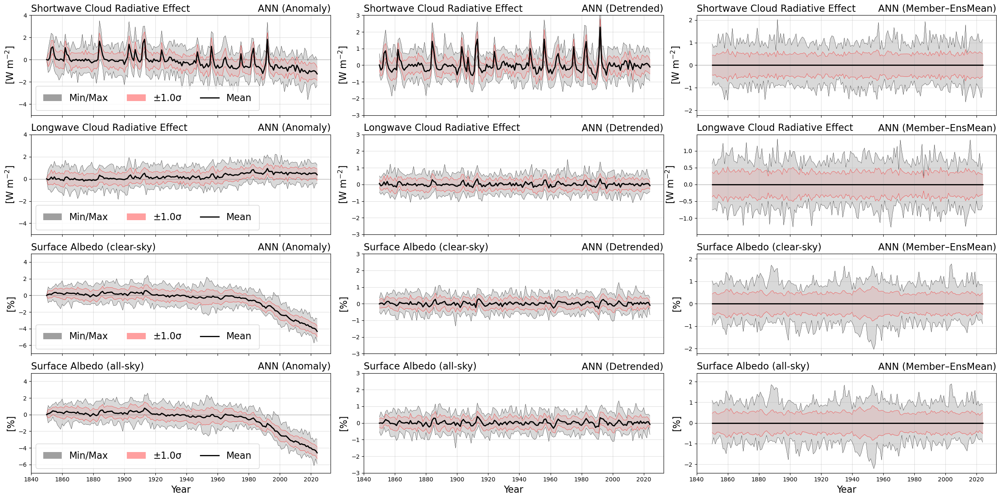

In [21]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "SWCF_SRF": {
            "name": "Shortwave Cloud Radiative Effect",
            "unit": "W m$^{-2}$",
            "min": -5.0, "max": 4.0, 
            "dmin": -3.0, "dmax": 3.0, 
            "nlev": 11,"scale": 1.0,   
        },
        "LWCF_SRF": {
            "name": "Longwave Cloud Radiative Effect",
            "unit": "W m$^{-2}$",
            "min": -5.0, "max": 4.0, 
            "dmin": -3.0, "dmax": 3.0, 
            "nlev": 11,"scale": 1.0,   
        },
        "ALBEDOC_SRF": {
            "name": "Surface Albedo (clear-sky)",
            "unit": "%",
            "min": -7, "max": 5, 
            "dmin": -3, "dmax": 3, 
            "nlev": 11, "scale": 100.0,   
        },
        "ALBEDO_SRF": {
            "name": "Surface Albedo (all-sky)",
            "unit": "%",
            "min": -7, "max": 5, 
            "dmin": -3, "dmax": 3, 
            "nlev": 11, "scale": 100.0,    
        },
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["SWCF_SRF", "LWCF_SRF", "ALBEDOC_SRF", "ALBEDO_SRF"]
    sub_dict = {k: var_dict[k] for k in sub_keys}
    
    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "iceVolume_imsk" for "iceVolume" (suffix mismatch).
variables for ensemble anomaly: iceVolume_imsk raw
variables for ensemble anomaly: SST raw
variables for ensemble anomaly: ALBEDOC_SRF raw
variables for ensemble anomaly: FSDSC raw
variables for ensemble anomaly: FLUSC raw
variables for ensemble anomaly: FLUS raw
variables for ensemble anomaly: FLDS raw
variables for ensemble anomaly: FLDSC raw
variables for ensemble anomaly: ALBEDO_SRF raw
variables for ensemble anomaly: SWCF_SRF raw
variables for ensemble anomaly: LWCF_SRF raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_a

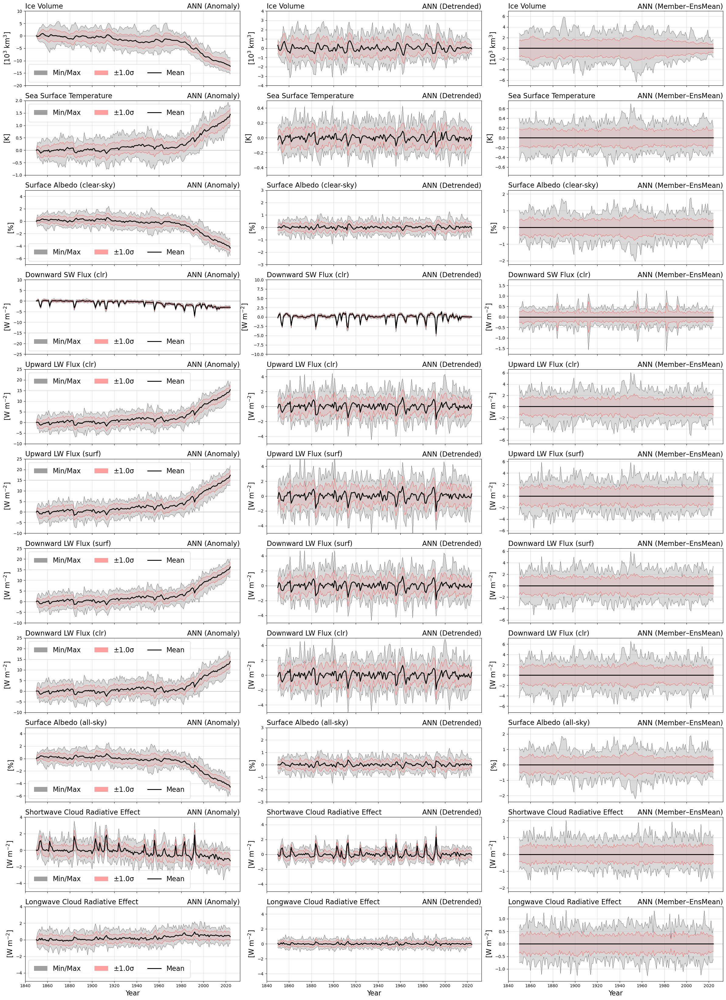

In [22]:
if __name__ == "__main__":
    import os
    from pathlib import Path

    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "iceVolume": {
            "name": "Ice Volume",
            "unit": r"10$^3$ km$^3$",
            "min": -20, "max": 10,
            "dmin": -4, "dmax": 4, 
            "nlev": 11, "scale": 1e-12,   # m^3 → 10^12 m^3 (≈ 10^3 km^3)
        },
        "SST": {
            "name": "Sea Surface Temperature",
            "unit": "K",
            "min": -1.0, "max": 2.0, 
            "dmin": -0.5, "dmax": 0.5, 
            "nlev": 11,"scale": 1.0,   
        },
        "ALBEDOC_SRF": {
            "name": "Surface Albedo (clear-sky)",
            "unit": "%",
            "min": -7, "max": 5, 
            "dmin": -3, "dmax": 3, 
            "nlev": 11, "scale": 100.0,   
        },
        "FSDSC": {
            "name": "Downward SW Flux (clr)",    
            "unit": r"W m$^{-2}$", 
            "min": -25, "max": 10, 
            "dmin": -10, "dmax": 10, 
            "nlev": 11, "scale": 1.0
        },
        "FLUSC": {
            "name": "Upward LW Flux (clr)",      
            "unit": r"W m$^{-2}$", 
            "min": -10, "max": 25, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11, "scale": 1.0
        },
        "FLUS": {
            "name": "Upward LW Flux (surf)",     
            "unit": r"W m$^{-2}$", 
            "min": -10, "max": 25, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11, "scale": 1.0
        },
        "FLDS": {
            "name": "Downward LW Flux (surf)",         
            "unit": r"W m$^{-2}$", 
            "min": -10, "max": 25, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11, "scale": 1.0
        },
        "FLDSC": {
            "name": "Downward LW Flux (clr)",    
            "unit": r"W m$^{-2}$", 
            "min": -10, "max": 25, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11, "scale": 1.0
        },
        "ALBEDO_SRF": {
            "name": "Surface Albedo (all-sky)",
            "unit": "%",
            "min": -7, "max": 5, 
            "dmin": -3, "dmax": 3, 
            "nlev": 11, "scale": 100.0,    
        },
        "SWCF_SRF": {
            "name": "Shortwave Cloud Radiative Effect",
            "unit": "W m$^{-2}$",
            "min": -5.0, "max": 4.0, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11,"scale": 1.0,   
        },
        "LWCF_SRF": {
            "name": "Longwave Cloud Radiative Effect",
            "unit": "W m$^{-2}$",
            "min": -5.0, "max": 4.0, 
            "dmin": -5, "dmax": 5, 
            "nlev": 11,"scale": 1.0,   
        },
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = list(overrides.keys()) #["SWCF_SRF", "LWCF_SRF", "ALBEDOC_SRF", "ALBEDO_SRF"]
    sub_dict = {k: var_dict[k] for k in sub_keys}
    
    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: SST raw
variables for ensemble anomaly: SICONC raw
[WARN] Using "DiceArea_imsk" for "DiceArea" (suffix mismatch).
[INFO] Remapped "DiceArea" -> "DiceArea_imsk".
[WARN] Using "DiceArea_imsk" for "DiceArea" (suffix mismatch).
[INFO] Remapped "DiceArea" -> "DiceArea_imsk".
[WARN] Using "DiceArea_imsk" for "DiceArea" (suffix mismatch).
[INFO] Remapped "DiceArea" -> "DiceArea_imsk".
[WARN] Using "iceArea_imsk" for "iceArea" (suffix mismatch).
variables for ensemble anomaly: iceArea_imsk raw
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "DiceVolume_imsk" for "DiceVolume" (suffix mismatch).
[INFO] Remapped "DiceVolume" -> "DiceVolume_imsk".
[WARN] Using "iceVolume_imsk" for "iceVolume" (suffix mismatch).
variables for en

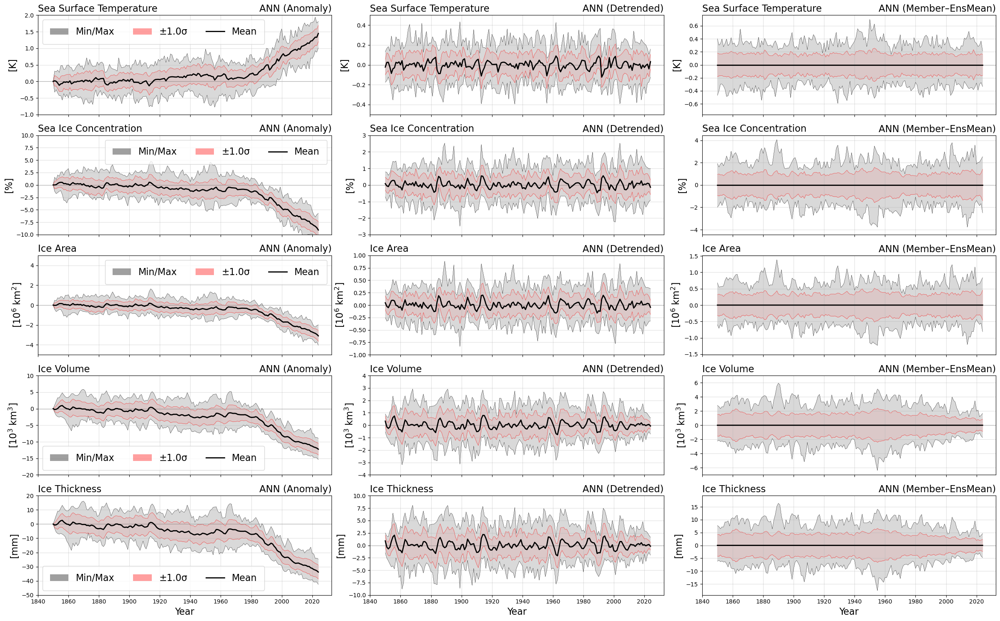

In [23]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "SST": {
            "name": "Sea Surface Temperature",
            "unit": "K",
            "min": -1.0, "max": 2.0, 
            "dmin": -0.5, "dmax": 0.5, 
            "nlev": 11,"scale": 1.0,   
        },
        "SICONC": {
            "name": "Sea Ice Concentration",
            "unit": "%",
            "min": -10, "max": 10, 
            "dmin": -3, "dmax": 3, 
            "nlev": 11,"scale": 1.0,   
        },
        "iceArea": {
            "name": "Ice Area",
            "unit": r"10$^6$ km$^2$",
            "min": -5, "max": 5, 
            "dmin": -1, "dmax": 1, 
            "nlev": 11, "scale": 1e-12,   # m^2 → 10^12 m^2 (≈ 10^6 km^2)
        },
        "iceVolume": {
            "name": "Ice Volume",
            "unit": r"10$^3$ km$^3$",
            "min": -20, "max": 10,
            "dmin": -4, "dmax": 4, 
            "nlev": 11, "scale": 1e-12,   # m^3 → 10^12 m^3 (≈ 10^3 km^3)
        },
        "iceThickness": {
            "name": "Ice Thickness",
            "unit": "mm",
            "min": -50, "max": 20, 
            "dmin": -10, "dmax": 10, 
            "nlev": 11,"scale": 1e3,
        },
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["SST", "SICONC", "iceArea", "iceVolume", "iceThickness"]
    sub_dict = {k: var_dict[k] for k in sub_keys}

    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: TURFLX raw
variables for ensemble anomaly: LHFLX raw
variables for ensemble anomaly: SHFLX raw
variables for ensemble anomaly: RADNET raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_anom_mean_std_panels.185001-202412.nens25.pdf


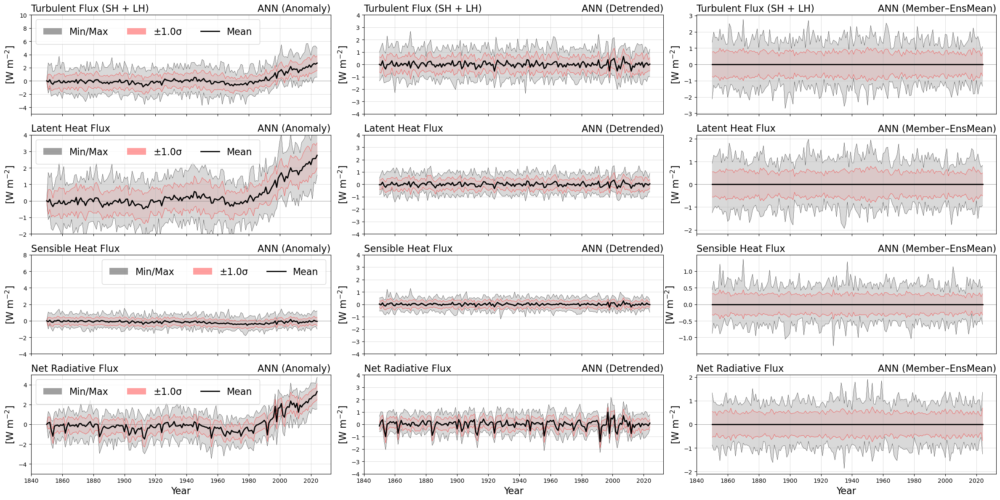

In [24]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        # --- flux and albedo additions ---
        "TURFLX":  {"name": "Turbulent Flux (SH + LH)",      
                    "unit": r"W m$^{-2}$", 
                    "min": -5, "max": 10, 
                    "dmin": -4, "dmax": 4, 
                    "nlev": 11, "scale": 1.0
                   },
        "LHFLX":   {"name": "Latent Heat Flux",              
                    "unit": r"W m$^{-2}$", 
                    "min": -2, "max": 4, 
                    "dmin": -4, "dmax": 4, 
                    "nlev": 11, "scale": 1.0
                   },
        "SHFLX":   {"name": "Sensible Heat Flux",            
                    "unit": r"W m$^{-2}$", 
                    "min": -4, "max": 8, 
                    "dmin": -4, "dmax": 4, 
                    "nlev": 11, "scale": 1.0
                   },
        "RADNET":  {"name": "Net Radiative Flux",            
                    "unit": r"W m$^{-2}$", 
                    "min": -5, "max": 5, 
                    "dmin": -4, "dmax": 4, 
                    "nlev": 11, "scale": 1.0
                   },
    }
    
    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["TURFLX", "LHFLX", "SHFLX", "RADNET"] 
    sub_dict = {k: var_dict[k] for k in sub_keys}

    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: RADNET raw
variables for ensemble anomaly: FSNS raw
variables for ensemble anomaly: FSNSC raw
variables for ensemble anomaly: FLNS raw
variables for ensemble anomaly: FLNSC raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_anom_mean_std_panels.185001-202412.nens25.pdf


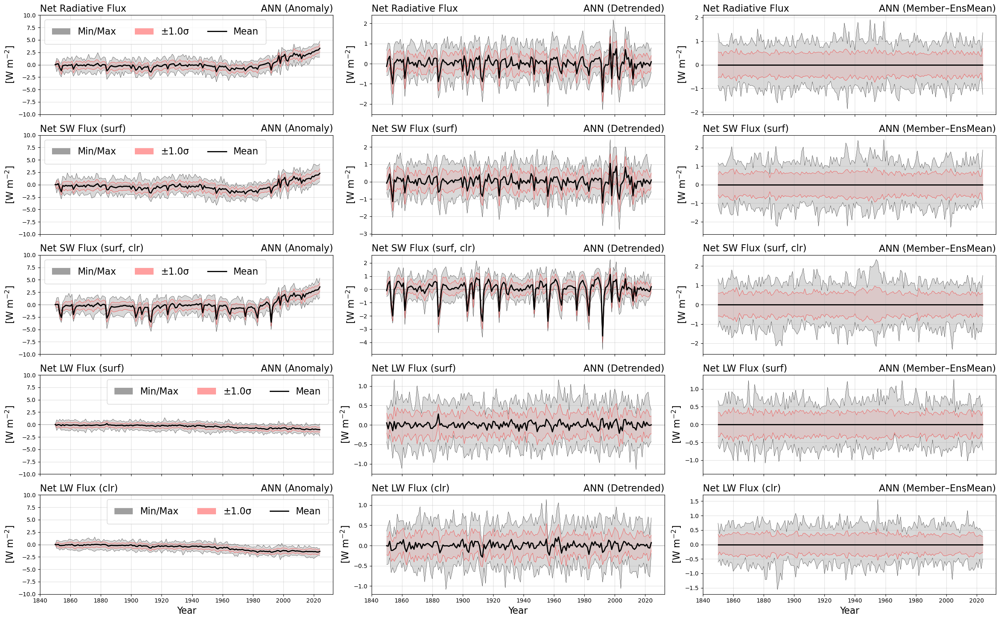

In [25]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "RADNET":      {"name": "Net Radiative Flux",        "unit": r"W m$^{-2}$", "min": -10, "max": 10, "nlev": 11, "scale": 1.0},
        "FSNS":        {"name": "Net SW Flux (surf)",        "unit": r"W m$^{-2}$", "min": -10, "max": 10, "nlev": 11, "scale": 1.0},
        "FSNSC":       {"name": "Net SW Flux (surf, clr)",   "unit": r"W m$^{-2}$", "min": -10, "max": 10, "nlev": 11, "scale": 1.0},
        "FLNS":        {"name": "Net LW Flux (surf)",        "unit": r"W m$^{-2}$", "min": -10, "max": 10, "nlev": 11, "scale": 1.0},
        "FLNSC":       {"name": "Net LW Flux (clr)",         "unit": r"W m$^{-2}$", "min": -10, "max": 10, "nlev": 11, "scale": 1.0},
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["RADNET", "FSNS", "FSNSC", "FLNS", "FLNSC"] 
    sub_dict = {k: var_dict[k] for k in sub_keys}

    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: FSNS raw
variables for ensemble anomaly: FSDS raw
variables for ensemble anomaly: FSUS raw
variables for ensemble anomaly: FSNSC raw
variables for ensemble anomaly: FSDSC raw
variables for ensemble anomaly: FSUSC raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_anom_mean_std_panels.185001-202412.nens25.pdf


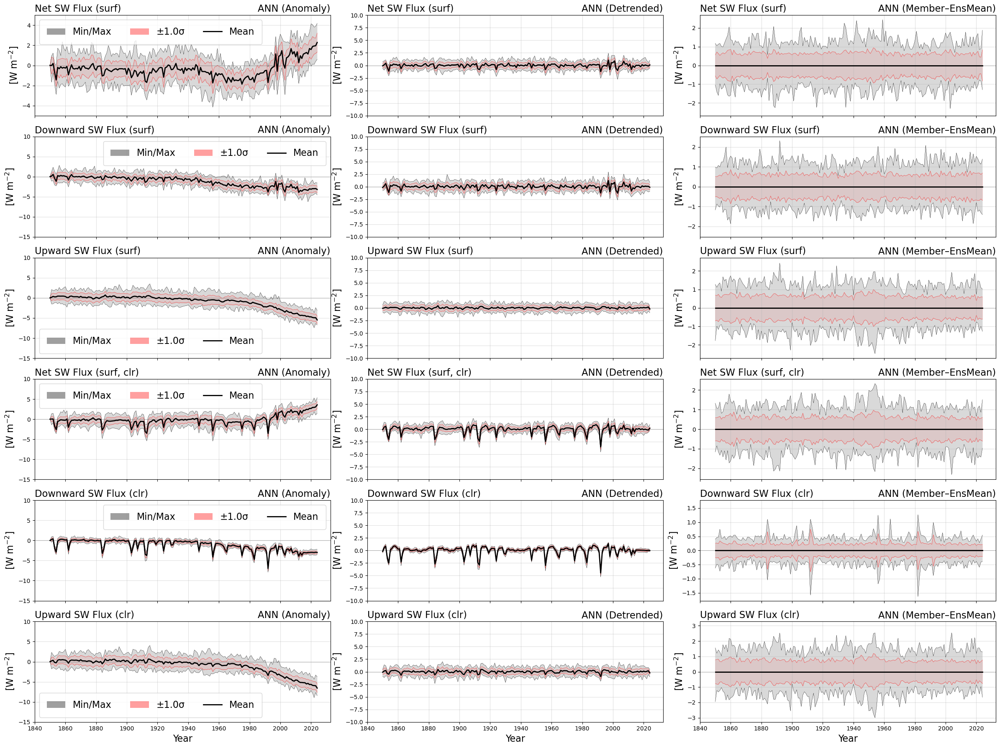

In [26]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "FSNS":        {"name": "Net SW Flux (surf)",        
                        "unit": r"W m$^{-2}$", 
                        "min": -5, "max": 5, 
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FSDS":        {"name": "Downward SW Flux (surf)",   
                        "unit": r"W m$^{-2}$",
                        "min": -15, "max": 10,
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FSUS":        {"name": "Upward SW Flux (surf)",     
                        "unit": r"W m$^{-2}$", 
                        "min": -15, "max": 10,
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FSNSC":       {"name": "Net SW Flux (surf, clr)",   
                        "unit": r"W m$^{-2}$", 
                        "min": -15, "max": 10,
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FSDSC":       {"name": "Downward SW Flux (clr)",    
                        "unit": r"W m$^{-2}$", 
                        "min": -15, "max": 10,
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FSUSC":       {"name": "Upward SW Flux (clr)",      
                        "unit": r"W m$^{-2}$", 
                        "min": -15, "max": 10,
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["FSNS", "FSDS", "FSUS", "FSNSC", "FSDSC", "FSUSC"] 
    sub_dict = {k: var_dict[k] for k in sub_keys}

    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )


[INFO] All ensemble files opened cleanly.
variables for ensemble anomaly: FLNS raw
variables for ensemble anomaly: FLDS raw
variables for ensemble anomaly: FLUS raw
variables for ensemble anomaly: FLNSC raw
variables for ensemble anomaly: FLDSC raw
variables for ensemble anomaly: FLUSC raw
[INFO] Saved: ./Arctic/v3.LR.historical.Arctic.annual_anom_mean_std_panels.185001-202412.nens25.pdf


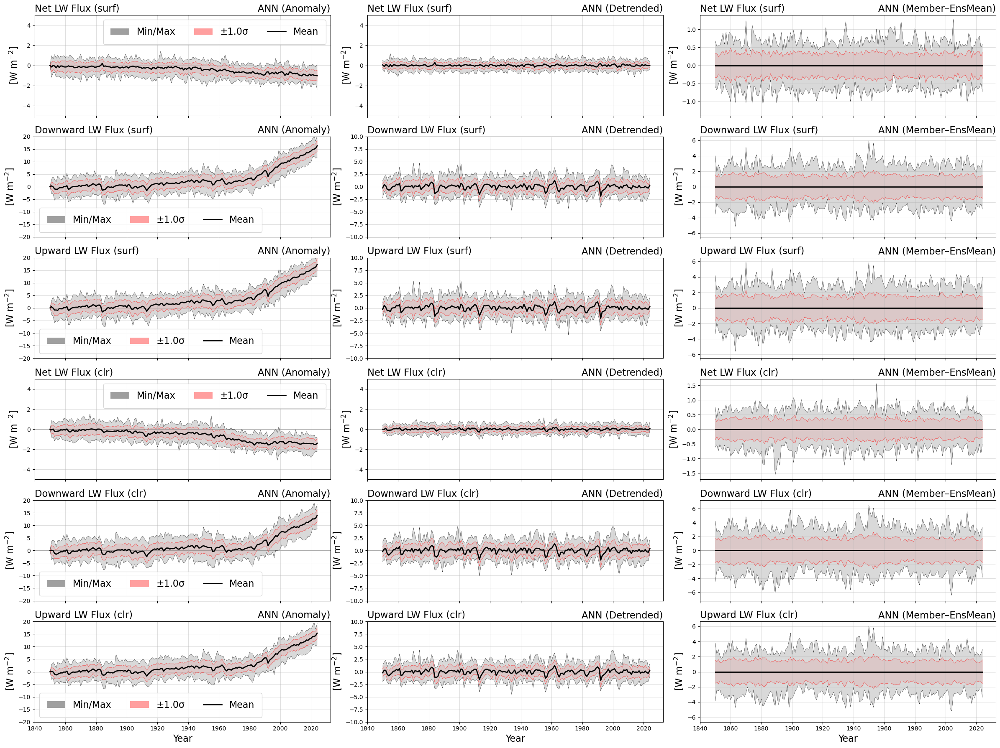

In [27]:
if __name__ == "__main__":
    # --- Paths
    data_dir = DATA_DIR
    fig_dir  = FIG_DIR
    
    # --- Ensemble naming / meta
    group  = "v3.LR.historical"
    regnam = "Arctic"
    nens   = 25
    period = "1850-2024"  # human-friendly span
    season = "ANN"        # annual mean 
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"

    # region-specific subdirs
    data_dir_reg = os.path.join(data_dir, regnam)
    fig_dir_reg  = os.path.join(fig_dir, regnam)
    Path(data_dir_reg).mkdir(parents=True, exist_ok=True)
    Path(fig_dir_reg).mkdir(parents=True, exist_ok=True)

    # --- Variables (units appear in y-labels)
    var_typ = "anomaly"  # or "raw"
    var_key = None

    overrides = {
        "FLNS":        {"name": "Net LW Flux (surf)",   
                        "unit": r"W m$^{-2}$", 
                        "min": -5, "max": 5, 
                        "dmin": -5, "dmax": 5, 
                        "nlev": 11, "scale": 1.0
                       },
        "FLDS":        {"name": "Downward LW Flux (surf)",         
                        "unit": r"W m$^{-2}$", 
                        "min": -20, "max": 20, 
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FLUS":        {"name": "Upward LW Flux (surf)",     
                        "unit": r"W m$^{-2}$", 
                        "min": -20, "max": 20, 
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FLNSC":       {"name": "Net LW Flux (clr)",         
                        "unit": r"W m$^{-2}$", 
                        "min": -5, "max": 5, 
                        "dmin": -5, "dmax": 5, 
                        "nlev": 11, "scale": 1.0
                       },
        "FLDSC":       {"name": "Downward LW Flux (clr)",    
                        "unit": r"W m$^{-2}$", 
                        "min": -20, "max": 20, 
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
        "FLUSC":       {"name": "Upward LW Flux (clr)",      
                        "unit": r"W m$^{-2}$", 
                        "min": -20, "max": 20, 
                        "dmin": -10, "dmax": 10, 
                        "nlev": 11, "scale": 1.0
                       },
    }

    # Merge reference dict + overrides
    var_dict = REFERENCE_VAR_DICT.copy()
    var_dict.update(overrides)

    # --- Subset for plotting (build from merged dict)
    sub_keys = ["FLNS", "FLDS", "FLUS", "FLNSC", "FLDSC", "FLUSC"] 
    sub_dict = {k: var_dict[k] for k in sub_keys}

    # Template with %(ENS) placeholder for zero-padded ensemble index
    file_template = f"{group}.en%(ENS).area_mean_ts.{date_span}.nc"

    enstr = f"{nens:02d}"
    fname = f"{group}.{regnam}.annual_anom_mean_std_panels.{date_span}.nens{enstr}.pdf"
    out_path = os.path.join(fig_dir_reg, fname)

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    ylim = "bounds"  # use per-variable min/max from sub_dict (merged var_dict)
    whiskers = {
        "type"       : "minmax",
        "line_pat"   : "-",
        "line_thk"   : 0.3,
        "line_col"   : "black",
        "percentile" : (5, 95),
        "show_band"  : True,
        "hatch_type" : "",
        "fill_alpha" : 0.15,
    }

    dpi = 600
    line_color   = "black"
    fill_color   = "red"
    fontz        = 16
    fig_width    = 24.0
    panel_height = 3.0
    row_space    = 0.6
    col_space    = 0.2

    # --- Create plotter
    plotter = AnnualAnomalyPlotter(
        data_dir=data_dir_reg,
        file_template=file_template,
        num_ens=nens,
        season=season,
        var_dict=var_dict,
        var_key=var_key,
        var_type=var_typ,
        fig_dir=fig_dir_reg,
        chunks={"year": 50},
        fontz=fontz,
    )

    # --- Plot (enable detrended right column)
    plotter.plot_time_series(
        sub_dict=sub_dict,
        spread=spread,
        sigma=sigma,
        rolling=rolling,
        separate_panels=separate_panels,
        out_path=out_path,
        dpi=dpi,
        fig_width=fig_width,
        panel_height=panel_height,
        row_space=row_space,
        col_space=col_space,
        line_color=line_color,
        fill_color=fill_color,
        whiskers=whiskers,
        ylim=ylim,
        sharey=False,
        apply_bounds=True,
        main_title=False,
        detrend_window=10,   # ← enables 2nd (detrended) column
        xlabels="bottom"     # cleaner x labels
    )
